In [ ]:
import pandas as pd
import oci 
from sklearn.model_selection import train_test_split
import oci
import matplotlib.pyplot as plt
import os
from oci.object_storage import UploadManager

In [2]:
data_path='local_data_path'
df=pd.read_csv(data_path)
df.shape

(1296675, 24)

In [3]:
# Split the data into training and production sets
# Using 5% for training and 95% for production
train_df, prod_df = train_test_split(df, test_size=0.50, random_state=42)

print(f"Training set shape: {train_df.shape}")
print(f"Production set shape: {prod_df.shape}")

Training set shape: (648337, 24)
Production set shape: (648338, 24)


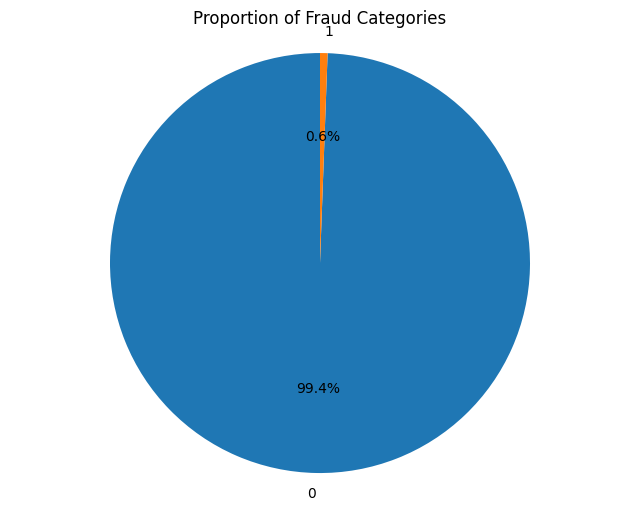

Class distribution:
is_fraud
0    644591
1      3746
Name: count, dtype: int64


In [4]:
# 1. Proportion of fraud categories (class distribution)
plt.figure(figsize=(8, 6))
fraud_counts = train_df['is_fraud'].value_counts()
plt.pie(fraud_counts.values, labels=fraud_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Fraud Categories')
plt.axis('equal')
plt.show()

print(f"Class distribution:")
print(fraud_counts)

In [11]:
config = oci.config.from_file()
object_storage_client = oci.object_storage.ObjectStorageClient(config)

namespace = object_storage_client.get_namespace().data

compartment_id='compartment_ocid'
bucket_name = 'your_bucket_name' 

In [13]:
local_path_train='your_training_local_path'
file_name_train='training_data_fraud_detection_kaggle_600.csv'

upload_manager = UploadManager(object_storage_client, allow_parallel_uploads=True)
upload_manager.upload_file(
    namespace_name=namespace,
    bucket_name=bucket_name,
    object_name=file_name_train,
    file_path=local_path_train
)

In [12]:
local_path_prod='your_production_local_path'

file_name_prod='production_data_fraud_detection_kaggle_600.csv'

upload_manager = UploadManager(object_storage_client, allow_parallel_uploads=True)
upload_manager.upload_file(
    namespace_name=namespace,
    bucket_name=bucket_name,
    object_name=file_name_prod,
    file_path=local_path_prod
)